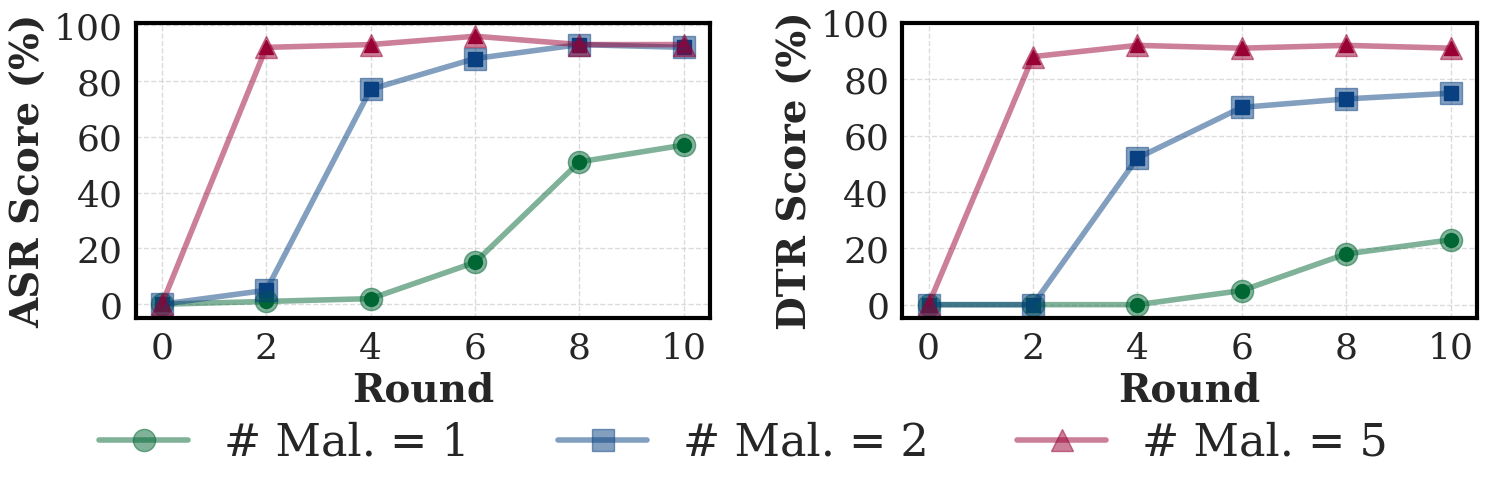

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define data
x_vals = [0, 2, 4, 6, 8, 10]
mal1_asr = [0, 1.0, 2.0, 15.0, 51.0, 56.99999999999999]
mal2_asr = [0, 5.0, 77.0, 88.0, 93.0, 92.0]
mal5_asr = [0, 92.0, 93.0, 96.0, 93.0, 93.0]

mal1_dtr = [0, 0.0, 0.0, 5.0, 18.0, 23.0]
mal2_dtr = [0, 0.0, 52.0, 70.0, 73.0, 75.0]
mal5_dtr = [0, 88.0, 92.0, 91.0, 92.0, 91.0]

# Prepare the dataframes
asr_data = pd.DataFrame({
    'x': np.tile(x_vals, 3),
    'y': mal1_asr + mal2_asr + mal5_asr,
    'type': ['mal_1']*6 + ['mal_2']*6 + ['mal_5']*6
})

dtr_data = pd.DataFrame({
    'x': np.tile(x_vals, 3),
    'y': mal1_dtr + mal2_dtr + mal5_dtr,
    'type': ['mal_1']*6 + ['mal_2']*6 + ['mal_5']*6
})

# Define colors and updated shapes
sci_colors = ['#006633', '#084081', '#990033']
shapes = ['o', 's', '^']  # Circle, Square, Triangle

# Set Seaborn style (academic)
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,  # Axis labels size
    "axes.titlesize": 20,  # Axis title size
    "xtick.labelsize": 18, # x-axis tick labels size
    "ytick.labelsize": 18, # y-axis tick labels size
    "font.family": "serif",
})

# Create the subplots with a more rectangular figure size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))  # Adjusted to make it more flat

# ASR plot
for i, mal_type in enumerate(['mal_1', 'mal_2', 'mal_5']):
    subset = asr_data[asr_data['type'] == mal_type]
    ax1.plot(subset['x'], subset['y'], label=mal_type, color=sci_colors[i], marker=shapes[i], markersize=16, linewidth=4, alpha=0.5)  # Lighter lines

# DTR plot
for i, mal_type in enumerate(['mal_1', 'mal_2', 'mal_5']):
    subset = dtr_data[dtr_data['type'] == mal_type]
    ax2.plot(subset['x'], subset['y'], label=mal_type, color=sci_colors[i], marker=shapes[i], markersize=16, linewidth=4, alpha=0.5)  # Lighter lines

# Add points with full opacity
for i, mal_type in enumerate(['mal_1', 'mal_2', 'mal_5']):
    subset = asr_data[asr_data['type'] == mal_type]
    ax1.scatter(subset['x'], subset['y'], color=sci_colors[i], marker=shapes[i], s=100, label=None)  # Points with full color intensity
    
    subset = dtr_data[dtr_data['type'] == mal_type]
    ax2.scatter(subset['x'], subset['y'], color=sci_colors[i], marker=shapes[i], s=100, label=None)  # Points with full color intensity

# Set common axis titles and gridlines
ax1.set_xlabel("Round", fontsize=28, weight='bold')
ax1.set_ylabel("ASR Score (%)", fontsize=28, weight='bold')
ax2.set_xlabel("Round", fontsize=28, weight='bold')
ax2.set_ylabel("DTR Score (%)", fontsize=28, weight='bold')

# Set x-axis and y-axis ticks
ax1.set_xticks(np.arange(0, 12, 2))
ax2.set_xticks(np.arange(0, 12, 2))
ax1.set_yticks(np.arange(0, 101, 20))
ax2.set_yticks(np.arange(0, 101, 20))

# Make tick labels larger
ax1.tick_params(axis='x', labelsize=26)  # Set larger size for x-ticks of ax1
ax1.tick_params(axis='y', labelsize=26)  # Set larger size for y-ticks of ax1
ax2.tick_params(axis='x', labelsize=26)  # Set larger size for x-ticks of ax2
ax2.tick_params(axis='y', labelsize=26)  # Set larger size for y-ticks of ax2

# Set gridlines
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.7)

# Modify legend labels
labels = ["# Mal. = 1", "# Mal. = 2", "# Mal. = 5"]

# Add legend with normal font weight for labels
handles, _ = ax1.get_legend_handles_labels()  # get legend handles from the first plot
fig.legend(handles, labels, title=None, loc='center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=False, fontsize=32)  # Default font weight for legend

# Black thicker outer border for both axes
for ax in [ax1, ax2]:
    for _, spine in ax.spines.items():
        spine.set_linewidth(3)  # Increase the border thickness
        spine.set_color('black')  # Change the border color to black

# Adjust layout to make it more spacious
fig.tight_layout(pad=4.0)
plt.subplots_adjust(bottom=0.25)  # Adjust the bottom margin to make space for the legend

# Save the plot with bbox_inches='tight' to ensure all elements are included
plt.savefig("combined_plot.pdf", format="pdf", bbox_inches='tight')

# Show plot
plt.show()


In [2]:
import numpy as np

# Original values
gpt_bp_sum = 0.06478173112216061
bandwidth_list = (1000, 100, 10, 1, 0.1, 0.01)
gpt_comm_sum = 0.9139519759586878

llama_comm_sum = 0.9368605017662048
llama_bp_sum = 0.05524348390513453

# Calculate communication time
gpt_comm_list = {}
llama_comm_list = {}
for bandwidth in bandwidth_list:
    gpt_comm_list[bandwidth] = gpt_comm_sum * 20 / bandwidth
    llama_comm_list[bandwidth] = llama_comm_sum * 20 / bandwidth

# Simulate BP time with small Gaussian noise
gpt_bp_list = {}
llama_bp_list = {}
noise_std_dev = 0.005  # Standard deviation for Gaussian noise, controlling fluctuation level

for bandwidth in bandwidth_list:
    noise = np.random.normal(0, noise_std_dev)  # Generate Gaussian noise
    gpt_bp_list[bandwidth] = gpt_bp_sum + noise  # Add noise to original BP time
    llama_bp_list[bandwidth] = llama_bp_sum + noise  # Add noise to original BP time

# Print the results
print("Communication Time (comm_list):")
print(f'gpt_comm_list: {gpt_comm_list}')
print(f'llama_comm_list: {llama_comm_list}')
print("\nBackpropagation Time with Noise (bp_list):")
print(f'gpt_bp_list: {gpt_bp_list}')
print(f'llama_bp_list: {llama_bp_list}')




Communication Time (comm_list):
gpt_comm_list: {1000: 0.018279039519173756, 100: 0.18279039519173756, 10: 1.8279039519173756, 1: 18.279039519173757, 0.1: 182.79039519173756, 0.01: 1827.9039519173757}
llama_comm_list: {1000: 0.018737210035324095, 100: 0.18737210035324098, 10: 1.8737210035324097, 1: 18.737210035324097, 0.1: 187.37210035324097, 0.01: 1873.7210035324097}

Backpropagation Time with Noise (bp_list):
gpt_bp_list: {1000: 0.06052180189860668, 100: 0.06449244316645837, 10: 0.05785679714540909, 1: 0.07219668599537302, 0.1: 0.05522336202059446, 0.01: 0.07273197979521225}
llama_bp_list: {1000: 0.050983554681580605, 100: 0.0549541959494323, 10: 0.04831854992838301, 1: 0.06265843877834694, 0.1: 0.045685114803568384, 0.01: 0.06319373257818617}


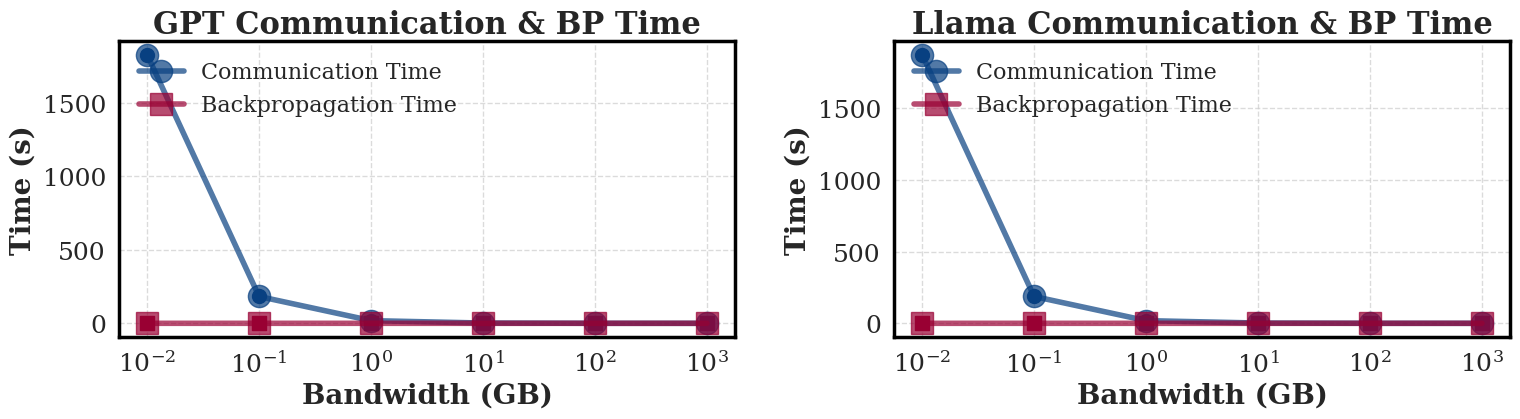

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define data
gpt_comm_list = {1000: 0.018279039519173756, 100: 0.18279039519173756, 10: 1.8279039519173756, 1: 18.279039519173757, 0.1: 182.79039519173756, 0.01: 1827.9039519173757}
llama_comm_list = {1000: 0.018737210035324095, 100: 0.18737210035324098, 10: 1.8737210035324097, 1: 18.737210035324097, 0.1: 187.37210035324097, 0.01: 1873.7210035324097}

gpt_bp_list = {1000: 0.06601198962123563, 100: 0.067796813371368, 10: 0.06495498197108977, 1: 0.07471148398652011, 0.1: 0.06131286621398462, 0.01: 0.07930698925477137}
llama_bp_list = {1000: 0.05647374240420955, 100: 0.05825856615434192, 10: 0.05541673475406369, 1: 0.06517323676949403, 0.1: 0.051774618996958545, 0.01: 0.06976874203774529}

# Prepare the dataframes
gpt_data = pd.DataFrame({
    'Bandwidth (GB)': list(gpt_comm_list.keys()),
    'Communication Time': list(gpt_comm_list.values()),
    'Backpropagation Time': list(gpt_bp_list.values())
})

llama_data = pd.DataFrame({
    'Bandwidth (GB)': list(llama_comm_list.keys()),
    'Communication Time': list(llama_comm_list.values()),
    'Backpropagation Time': list(llama_bp_list.values())
})

# Set Seaborn style (academic)
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,  # Axis labels size
    "axes.titlesize": 20,  # Axis title size
    "xtick.labelsize": 18, # x-axis tick labels size
    "ytick.labelsize": 18, # y-axis tick labels size
    "font.family": "serif",
})

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))  # Adjusted to make it more flat

# GPT Plot
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['Communication Time'], label="Communication Time", color='#084081', marker='o', markersize=16, linewidth=4, alpha=0.7)
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['Backpropagation Time'], label="Backpropagation Time", color='#990033', marker='s', markersize=16, linewidth=4, alpha=0.7)

ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['Communication Time'], color='#084081', marker='o', s=100)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['Backpropagation Time'], color='#990033', marker='s', s=100)

# Llama Plot
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['Communication Time'], label="Communication Time", color='#084081', marker='o', markersize=16, linewidth=4, alpha=0.7)
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['Backpropagation Time'], label="Backpropagation Time", color='#990033', marker='s', markersize=16, linewidth=4, alpha=0.7)

ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['Communication Time'], color='#084081', marker='o', s=100)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['Backpropagation Time'], color='#990033', marker='s', s=100)

# Set axis titles and gridlines
ax1.set_xlabel("Bandwidth (GB)", fontsize=20, weight='bold')
ax1.set_ylabel("Time (s)", fontsize=20, weight='bold')
ax1.set_title("GPT Communication & BP Time", fontsize=22, weight='bold')

ax2.set_xlabel("Bandwidth (GB)", fontsize=20, weight='bold')
ax2.set_ylabel("Time (s)", fontsize=20, weight='bold')
ax2.set_title("Llama Communication & BP Time", fontsize=22, weight='bold')

# Log scale for x-axis
ax1.set_xscale('log')
ax2.set_xscale('log')

# Gridlines
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.7)

# Legends
ax1.legend(fontsize=16, loc='upper left', frameon=False)
ax2.legend(fontsize=16, loc='upper left', frameon=False)

# Black thicker outer border
for ax in [ax1, ax2]:
    for _, spine in ax.spines.items():
        spine.set_linewidth(2.5)
        spine.set_color('black')

# Adjust layout to make it more spacious
fig.tight_layout(pad=3.0)

# Save the plot
plt.savefig("comm_bp_time_plot.pdf", format="pdf", bbox_inches='tight')

# Show plot
plt.show()

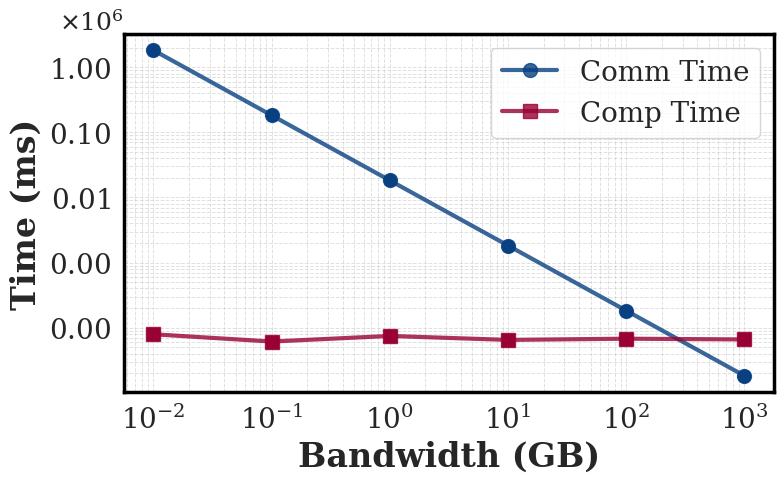

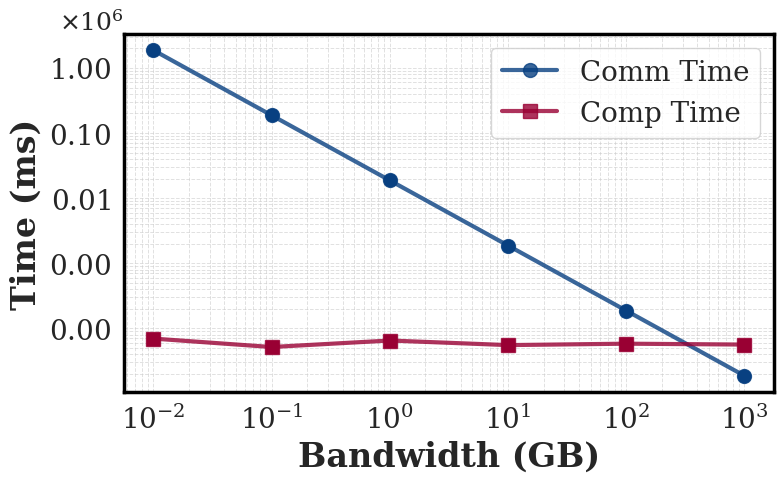

In [10]:
from matplotlib.ticker import LogLocator, ScalarFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data preparation
gpt_comm_list = {1000: 0.018279039519173756, 100: 0.18279039519173756, 10: 1.8279039519173756, 1: 18.279039519173757, 0.1: 182.79039519173756, 0.01: 1827.9039519173757}
llama_comm_list = {1000: 0.018737210035324095, 100: 0.18737210035324098, 10: 1.8737210035324097, 1: 18.737210035324097, 0.1: 187.37210035324097, 0.01: 1873.7210035324097}

gpt_bp_list = {1000: 0.06601198962123563, 100: 0.067796813371368, 10: 0.06495498197108977, 1: 0.07471148398652011, 0.1: 0.06131286621398462, 0.01: 0.07930698925477137}
llama_bp_list = {1000: 0.05647374240420955, 100: 0.05825856615434192, 10: 0.05541673475406369, 1: 0.06517323676949403, 0.1: 0.051774618996958545, 0.01: 0.06976874203774529}

gpt_data = pd.DataFrame({
    'Bandwidth (GB)': list(gpt_comm_list.keys()),
    'Communication Time': list(gpt_comm_list.values()),
    'Backpropagation Time': list(gpt_bp_list.values())
})

llama_data = pd.DataFrame({
    'Bandwidth (GB)': list(llama_comm_list.keys()),
    'Communication Time': list(llama_comm_list.values()),
    'Backpropagation Time': list(llama_bp_list.values())
})

# Style settings
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.family": "serif",
})

# GPT Plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['Communication Time'], label="Comm Time", color='#084081', marker='o', markersize=10, linewidth=3, alpha=0.8)
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['Backpropagation Time'], label="Comp Time", color='#990033', marker='s', markersize=10, linewidth=3, alpha=0.8)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['Communication Time'], color='#084081', marker='o', s=80)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['Backpropagation Time'], color='#990033', marker='s', s=80)

ax1.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax1.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')

# Dynamic gridlines
ax1.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax1.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

ax1.legend(fontsize=20, loc='upper right', frameon=True)
for _, spine in ax1.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("gpt_training_time_dynamic_grid.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Llama Plot
fig, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['Communication Time'], label="Comm Time", color='#084081', marker='o', markersize=10, linewidth=3, alpha=0.8)
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['Backpropagation Time'], label="Comp Time", color='#990033', marker='s', markersize=10, linewidth=3, alpha=0.8)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['Communication Time'], color='#084081', marker='o', s=80)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['Backpropagation Time'], color='#990033', marker='s', s=80)

ax2.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax2.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')

# Dynamic gridlines
ax2.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax2.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax2.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax2.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

ax2.legend(fontsize=20, loc='upper right', frameon=True)
for _, spine in ax2.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("llama_training_time_dynamic_grid.pdf", format="pdf", bbox_inches='tight')
plt.show()


In [5]:
def cal_sgd(total_iterations, train_time, comm_time):
  time_sum = 0
  time_per_iter = train_time + comm_time
  for i in range(total_iterations):
    time_sum += time_per_iter
  return time_sum / total_iterations

def cal_pipe_sgd(total_iterations, train_time, comm_time):
  time_sum = 0
  time_per_iter = train_time + comm_time * 0.6
  for i in range(total_iterations):
    time_sum += time_per_iter
  return time_sum / total_iterations

def cal_localsgd(total_iterations,nsteps_localsgd, train_time, comm_time):
  time_sum = 0
#   train_time = time_dict[dnn][nworkers]['train']
#   comm_time = time_dict[dnn][nworkers]['comm']
  for i in range(total_iterations):
    if(i != 0 and i % nsteps_localsgd == 0):
      time_sum += (train_time + comm_time)
    else:
      time_sum += train_time

  return time_sum / total_iterations


def cal_dreamddp(total_iterations, H, waittime_per_H, train_time):
  time_sum = 0
#   train_time = time_dict[dnn][nworkers]['train']
#   comm_time = time_dict[dnn][nworkers]['comm']
  for i in range(total_iterations):
    if(i != 0 and i % H == 0):
      time_sum += (train_time + waittime_per_H)
    else:
      time_sum += train_time

  return time_sum / total_iterations

def cal_pipe_seq_localsgd(total_iterations, H, wait_list, train_time):
  time_dict = {}
  time_sum = 0
#   train_time = time_dict[dnn][nworkers]['train']
#   comm_time = time_dict[dnn][nworkers]['comm']
  for i in range(total_iterations):
    time_sum += (train_time + wait_list[i%H])

  return time_sum / total_iterations


In [6]:
import numpy as np

# Original values
gpt_bp_sum = 0.06478173112216061
bandwidth_list = (1000, 100, 10, 1, 0.1, 0.01)
gpt_comm_sum = 0.9139519759586878

llama_comm_sum = 0.9368605017662048
llama_bp_sum = 0.05524348390513453

# Calculate communication time
gpt_total_time_localsgd = {}
llama_total_time_localsgd = {}
gpt_total_time_sgd = {}
llama_total_time_sgd = {}
for bandwidth in bandwidth_list:
    gpt_comm_time = gpt_comm_sum * 20 / bandwidth
    llama_comm_time = llama_comm_sum * 20 / bandwidth
    gpt_total_time_localsgd[bandwidth] = cal_localsgd(190,10,gpt_bp_sum,gpt_comm_time) *190
    llama_total_time_localsgd[bandwidth] = cal_localsgd(220,10,llama_bp_sum,llama_comm_time) *220
    gpt_total_time_sgd[bandwidth] = cal_sgd(190,gpt_bp_sum,gpt_comm_time) *190
    llama_total_time_sgd[bandwidth] = cal_sgd(220,llama_bp_sum,llama_comm_time) *220

print(f'gpt_total_time_localsgd: {gpt_total_time_localsgd}')
print(f'llama_total_time_localsgd: {llama_total_time_localsgd}')
print(f'gpt_total_time_sgd: {gpt_total_time_sgd}')
print(f'llama_total_time_sgd: {llama_total_time_sgd}')



gpt_total_time_localsgd: {1000: 12.637551624555627, 100: 15.598756026661764, 10: 45.21080004772323, 1: 341.33124025833786, 0.1: 3302.535642364498, 0.01: 32914.57966342597}
llama_total_time_localsgd: {1000: 12.547047869871351, 100: 16.088380566547578, 10: 51.50170753331034, 1: 405.634977200937, 0.1: 3946.967673877181, 0.01: 39360.29464063966}
gpt_total_time_sgd: {1000: 15.78154642185346, 100: 47.03870399964061, 10: 359.6102797775111, 1: 3485.3260375562318, 0.1: 34742.48361534317, 0.01: 347314.05939321424}
llama_total_time_sgd: {1000: 16.27575266690099, 100: 53.37542853684238, 10: 424.3721872362611, 1: 4134.339774230423, 0.1: 41234.01564417207, 0.01: 412230.77434359136}


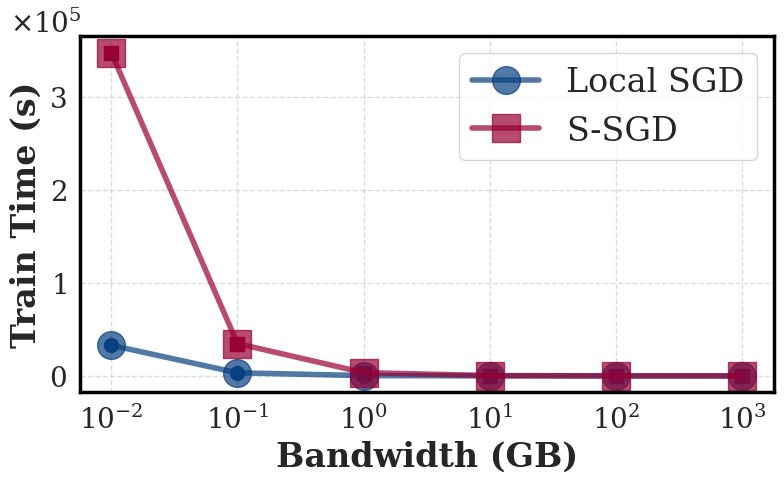

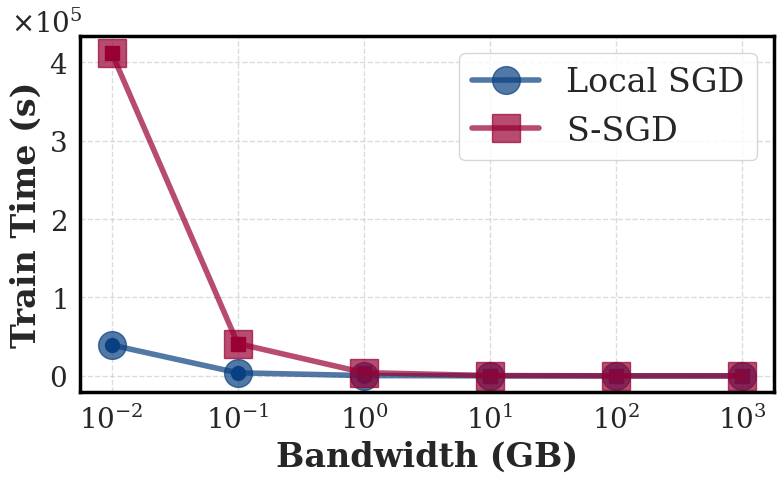

In [7]:
from matplotlib.ticker import ScalarFormatter
gpt_data = pd.DataFrame({
    'Bandwidth (GB)': list(gpt_total_time_localsgd.keys()),
    'LocalSGD Time': list(gpt_total_time_localsgd.values()),
    'SGD Time': list(gpt_total_time_sgd.values())
})

llama_data = pd.DataFrame({
    'Bandwidth (GB)': list(llama_total_time_localsgd.keys()),
    'LocalSGD Time': list(llama_total_time_localsgd.values()),
    'SGD Time': list(llama_total_time_sgd.values())
})

# Set Seaborn style (academic)
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,  # Axis labels size
    "axes.titlesize": 20,  # Axis title size
    "xtick.labelsize": 20, # x-axis tick labels size
    "ytick.labelsize": 20, # y-axis tick labels size
    "font.family": "serif",
})

# GPT Plot
fig, ax1 = plt.subplots(figsize=(8, 5))  # Create a single plot for GPT
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['LocalSGD Time'], label="Local SGD", color='#084081', marker='o', markersize=20, linewidth=4, alpha=0.7)
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['SGD Time'], label="S-SGD", color='#990033', marker='s', markersize=20, linewidth=4, alpha=0.7)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['LocalSGD Time'], color='#084081', marker='o', s=100)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['SGD Time'], color='#990033', marker='s', s=100)

ax1.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax1.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax1.set_xscale('log')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=24, loc='upper right', frameon=True)

# Use scientific notation for y-axis
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Adjust position of scientific notation offset text
offset_text = ax1.yaxis.get_offset_text()
offset_text.set_x(-0.1)  # Move slightly to the left
offset_text.set_y(0.0)    # Move slightly down, within the axis

# Black thicker outer border
for _, spine in ax1.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("gpt_training_time_plot.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Llama Plot
fig, ax2 = plt.subplots(figsize=(8, 5))  # Create a single plot for Llama
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['LocalSGD Time'], label="Local SGD", color='#084081', marker='o', markersize=20, linewidth=4, alpha=0.7)
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['SGD Time'], label="S-SGD", color='#990033', marker='s', markersize=20, linewidth=4, alpha=0.7)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['LocalSGD Time'], color='#084081', marker='o', s=100)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['SGD Time'], color='#990033', marker='s', s=100)

ax2.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax2.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax2.set_xscale('log')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=24, loc='upper right', frameon=True)

# Use scientific notation for y-axis
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Adjust position of scientific notation offset text
offset_text = ax2.yaxis.get_offset_text()
offset_text.set_x(-0.1)  # Move slightly to the left
offset_text.set_y(0.0)    # Move slightly down, within the axis

# Black thicker outer border
for _, spine in ax2.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("llama_training_time_plot.pdf", format="pdf", bbox_inches='tight')
plt.show()

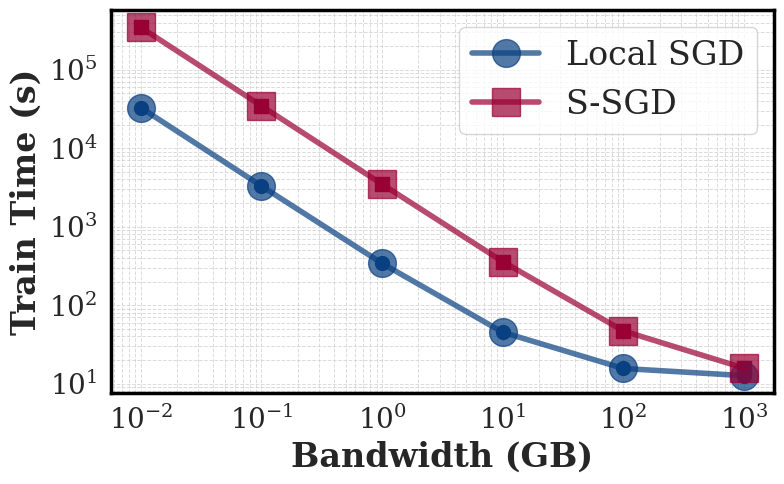

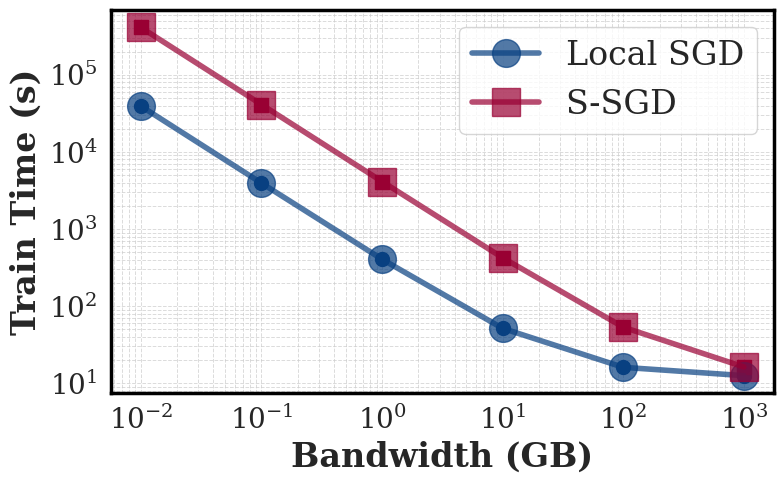

In [8]:
from matplotlib.ticker import ScalarFormatter, LogLocator
import seaborn as sns

# Data for GPT and Llama plots
gpt_data = pd.DataFrame({
    'Bandwidth (GB)': list(gpt_total_time_localsgd.keys()),
    'LocalSGD Time': list(gpt_total_time_localsgd.values()),
    'SGD Time': list(gpt_total_time_sgd.values())
})

llama_data = pd.DataFrame({
    'Bandwidth (GB)': list(llama_total_time_localsgd.keys()),
    'LocalSGD Time': list(llama_total_time_localsgd.values()),
    'SGD Time': list(llama_total_time_sgd.values())
})

# Set Seaborn style (academic)
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.family": "serif",
})

# GPT Plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['LocalSGD Time'], label="Local SGD", color='#084081', marker='o', markersize=20, linewidth=4, alpha=0.7)
ax1.plot(gpt_data['Bandwidth (GB)'], gpt_data['SGD Time'], label="S-SGD", color='#990033', marker='s', markersize=20, linewidth=4, alpha=0.7)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['LocalSGD Time'], color='#084081', marker='o', s=100)
ax1.scatter(gpt_data['Bandwidth (GB)'], gpt_data['SGD Time'], color='#990033', marker='s', s=100)

# Set axis labels and scales
ax1.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax1.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')

# Add dynamic gridlines
ax1.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax1.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Adjust legend and border
ax1.legend(fontsize=24, loc='upper right', frameon=True)
for _, spine in ax1.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("gpt_training_time_plot_dynamic_log.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Llama Plot
fig, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['LocalSGD Time'], label="Local SGD", color='#084081', marker='o', markersize=20, linewidth=4, alpha=0.7)
ax2.plot(llama_data['Bandwidth (GB)'], llama_data['SGD Time'], label="S-SGD", color='#990033', marker='s', markersize=20, linewidth=4, alpha=0.7)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['LocalSGD Time'], color='#084081', marker='o', s=100)
ax2.scatter(llama_data['Bandwidth (GB)'], llama_data['SGD Time'], color='#990033', marker='s', s=100)

# Set axis labels and scales
ax2.set_xlabel("Bandwidth (GB)", fontsize=24, weight='bold')
ax2.set_ylabel("Train Time (s)", fontsize=24, weight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')

# Add dynamic gridlines
ax2.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax2.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax2.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax2.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Adjust legend and border
ax2.legend(fontsize=24, loc='upper right', frameon=True)
for _, spine in ax2.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

plt.tight_layout()
plt.savefig("llama_training_time_plot_dynamic_log.pdf", format="pdf", bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Parameters for each model
models = ['ResNet-18', 'ResNet-50', 'GPT-2', 'Llama-2']
layers = [46, 119, 125, 91]  # Number of layers in each model
H = 10  # Number of iterations

# Calculate time complexity for brute force and our scheduling algorithm
brute_force_time = [
    np.math.factorial(L) / (np.math.factorial(H) * np.math.factorial(L - H))
    for L in layers
]
print(f'brute_force_time: {brute_force_time}')
scheduling_time = [2 ** min(L - H, H) for L in layers]

print(f'scheduling_time: {scheduling_time}')
# Plotting configuration
fig, ax = plt.subplots(figsize=(8, 5))  # Create a single plot for all models
x_positions = np.arange(len(models))  # Positions for model names on x-axis

# Plot brute force and scheduling times
ax.plot(x_positions, brute_force_time, label="Brute Force", color='#990033', marker='o', markersize=20, linewidth=4, alpha=0.7)
ax.plot(x_positions, scheduling_time, label="DreamDDP", color='#084081', marker='s', markersize=20, linewidth=4, alpha=0.7)
ax.scatter(x_positions, brute_force_time, color='#990033', marker='o', s=100)
ax.scatter(x_positions, scheduling_time, color='#084081', marker='s', s=100)

# Set x-axis with model names
ax.set_xticks(x_positions)
ax.set_xticklabels(models, fontsize=22)
ax.set_xlabel("Model", fontsize=24)

# Set y-axis with logarithmic scale
ax.set_ylabel("Time Complexity", fontsize=24)
ax.set_yscale('log')  # Set y-axis to logarithmic scale

# Adjust y-axis tick label size
ax.tick_params(axis='y', labelsize=24)  # Increase y-axis tick label size
ax.grid(True, linestyle='--', alpha=0.7, which='both')  # Both major and minor gridlines

# Add legend
ax.legend(fontsize=24, loc='best', frameon=True)

# Black thicker outer border
for _, spine in ax.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("time_complexity.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
import itertools

def pipe_seq_localsgd_waittime(bp_dict, comm_dict, H, layer_combination):
    wait_list = []
    layers = list(comm_dict.keys())
    num_layers = len(layers)

    def find_fallin(rest, index, bp_index):
        if comm_dict[layers[index]] <= rest:
            return bp_index, rest - comm_dict[layers[index]]
        else:
            fall_idx = 0
            rest_time = 0
            if rest == 0:
                total = comm_dict[layers[index]]
                sum = 0
                for i in range(bp_index, num_layers):
                    sum += bp_dict[layers[i]]
                    if total <= sum:
                        fall_idx = i
                        rest_time = sum - total
                        if rest_time == 0:
                            fall_idx += 1
                        break
            else:
                total = comm_dict[layers[index]] - rest
                sum = 0
                for i in range(bp_index + 1, num_layers):
                    sum += bp_dict[layers[i]]
                    if total <= sum:
                        fall_idx = i
                        rest_time = sum - total
                        if rest_time == 0:
                            fall_idx += 1
                        break
            return fall_idx, rest_time

    def get_remaining_bptime(rest, index):
        if index == num_layers:
            return 0
        bp_sum = 0
        for i in range(index, num_layers):
            bp_sum += bp_dict[layers[i]]
        return bp_sum if rest == 0 else bp_sum - (bp_dict[layers[index]] - rest)

    def get_waittime(layer_indices):
        bp_idx = layer_indices[0] + 1
        total_wait_time = 0
        rest = 0
        for i in layer_indices:
            if i == bp_idx:
                bp_idx += 1
                rest = 0
            remaining = get_remaining_bptime(rest, bp_idx)
            if comm_dict[layers[i]] >= remaining:
                wait_time = comm_dict[layers[i]] - remaining
                total_wait_time += wait_time
                for j in range(i + 1, num_layers):
                    total_wait_time += comm_dict[layers[j]]
                return total_wait_time
            else:
                fall_idx, rest_time = find_fallin(rest, i, bp_idx)
                bp_idx = fall_idx
                rest = rest_time
        return total_wait_time

    # Calculate wait time for each iteration
    for indices in layer_combination:
        wt = get_waittime(indices)
        wait_list.append(wt)
    return sum(wait_list)


def brute_force_optimal_split(bp_dict, comm_dict, H):
    layers = list(comm_dict.keys())
    num_layers = len(layers)

    # Generate all possible combinations for H iterations
    all_combinations = []
    for split in itertools.combinations(range(1, num_layers), H - 1):
        split_indices = [0] + list(split) + [num_layers]
        layer_combination = [list(range(split_indices[i], split_indices[i + 1])) for i in range(H)]
        all_combinations.append(layer_combination)

    # Find the optimal combination with minimum wait time
    min_time = float('inf')
    best_combination = None
    for combination in all_combinations:
        total_time = pipe_seq_localsgd_waittime(bp_dict, comm_dict, H, combination)
        if total_time < min_time:
            min_time = total_time
            best_combination = combination

    return min_time, best_combination


# Example usage:
bp_dict = {'L1': 2, 'L2': 3, 'L3': 5, 'L4': 7}
comm_dict = {'L1': 3, 'L2': 4, 'L3': 6, 'L4': 8}
H = 2

min_time, best_combination = brute_force_optimal_split(bp_dict, comm_dict, H)
print(f"Minimum Wait Time: {min_time}")
print(f"Best Combination: {best_combination}")


In [16]:
bp_dict_resnet18_32 = {
    "conv1": 3.4662393423227164e-05,
    "bn1": 0.0006718085362361028,
    "layer1.0.conv1": 0.001868743162888747,
    "layer1.0.bn1": 0.0005046771122859075,
    "layer1.0.conv2": 0.0018584361443152795,
    "layer1.0.bn2": 0.00035535372220552887,
    "layer1.0.shortcut": 0.0003738953517033504,
    "layer1.1.conv1": 0.001856051958524264,
    "layer1.1.bn1": 0.0005065111013559195,
    "layer1.1.conv2": 0.002038680590116061,
    "layer1.1.bn2": 0.0003620661222017728,
    "layer1.1.shortcut": 0.0003742804894080529,
    "layer2.0.conv1": 0.0016319201542780949,
    "layer2.0.bn1": 0.00027361282935509313,
    "layer2.0.conv2": 0.0009852922879732572,
    "layer2.0.bn2": 0.00020749752338115985,
    "layer2.0.shortcut.0": 0.0013576104090763973,
    "layer2.0.shortcut.1": 0.00035584889925443207,
    "layer2.1.conv1": 0.0009839167961707483,
    "layer2.1.bn1": 0.0002778126643254207,
    "layer2.1.conv2": 0.00121155151954064,
    "layer2.1.bn2": 0.00021520027747521034,
    "layer2.1.shortcut": 0.00021257767310509316,
    "layer3.0.conv1": 0.0013115956233097957,
    "layer3.0.bn1": 0.00020186717693622297,
    "layer3.0.conv2": 0.0007226833930382362,
    "layer3.0.bn2": 0.0001735687255859375,
    "layer3.0.shortcut.0": 0.0010004593775822567,
    "layer3.0.shortcut.1": 0.00025472274193396937,
    "layer3.1.conv1": 0.0007182451394888071,
    "layer3.1.bn1": 0.00022455362173227163,
    "layer3.1.conv2": 0.0009306760934682993,
    "layer3.1.bn2": 0.00017978594853327825,
    "layer3.1.shortcut": 0.0001593919900747446,
    "layer4.0.conv1": 0.003095351732694186,
    "layer4.0.bn1": 0.0002373365255502554,
    "layer4.0.conv2": 0.0008761699383075421,
    "layer4.0.bn2": 0.00018117978022648738,
    "layer4.0.shortcut.0": 0.0014220201052152193,
    "layer4.0.shortcut.1": 0.000273594489464393,
    "layer4.1.conv1": 0.0008259369776799128,
    "layer4.1.bn1": 0.000241242922269381,
    "layer4.1.conv2": 0.002770680647629958,
    "layer4.1.bn2": 0.0010690505688007062,
    "layer4.1.shortcut": 0.001104593276977539,
    "linear": 0.002290175511286809
}
comm_dict_resnet18_32 = {
    "conv1": 0.007213592529296875,
    "bn1": 0.001416921615600586,
    "layer1.0.conv1": 0.0034110546112060547,
    "layer1.0.bn1": 0.0014524459838867188,
    "layer1.0.conv2": 0.0033490657806396484,
    "layer1.0.bn2": 0.0013031959533691406,
    "layer1.0.shortcut": 0.0001671314239501953,
    "layer1.1.conv1": 0.003930091857910156,
    "layer1.1.bn1": 0.0013790130615234375,
    "layer1.1.conv2": 0.0034716129302978516,
    "layer1.1.bn2": 0.0014393329620361328,
    "layer1.1.shortcut": 0.00019669532775878906,
    "layer2.0.conv1": 0.005247354507446289,
    "layer2.0.bn1": 0.0015451908111572266,
    "layer2.0.conv2": 0.010055780410766602,
    "layer2.0.bn2": 0.0014810562133789062,
    "layer2.0.shortcut.0": 0.0025568008422851562,
    "layer2.0.shortcut.1": 0.0026144981384277344,
    "layer2.1.conv1": 0.010305166244506836,
    "layer2.1.bn1": 0.001577138900756836,
    "layer2.1.conv2": 0.010154485702514648,
    "layer2.1.bn2": 0.0014967918395996094,
    "layer2.1.shortcut": 3.62396240234375e-05,
    "layer3.0.conv1": 0.01981067657470703,
    "layer3.0.bn1": 0.0017261505126953125,
    "layer3.0.conv2": 0.03934144973754883,
    "layer3.0.bn2": 0.0019450187683105469,
    "layer3.0.shortcut.0": 0.003335714340209961,
    "layer3.0.shortcut.1": 0.004312038421630859,
    "layer3.1.conv1": 0.03931856155395508,
    "layer3.1.bn1": 0.0045185089111328125,
    "layer3.1.conv2": 0.039600372314453125,
    "layer3.1.bn2": 0.0017468929290771484,
    "layer3.1.shortcut": 3.838539123535156e-05,
    "layer4.0.conv1": 0.0784757137298584,
    "layer4.0.bn1": 0.001903533935546875,
    "layer4.0.conv2": 0.15665006637573242,
    "layer4.0.bn2": 0.0017650127410888672,
    "layer4.0.shortcut.0": 0.009269475936889648,
    "layer4.0.shortcut.1": 0.001957416534423828,
    "layer4.1.conv1": 0.15675950050354004,
    "layer4.1.bn1": 0.0018436908721923828,
    "layer4.1.conv2": 0.15674829483032227,
    "layer4.1.bn2": 0.003426790237426758,
    "layer4.1.shortcut": 3.147125244140625e-05,
    "linear": 0.0033216476440429688
}

In [ ]:
def truncate_dicts(bp_dict, comm_dict, Num):
    """
    Truncate the given dictionaries to keep only the first `Num` elements.

    Args:
        bp_dict (dict): Dictionary of backward propagation times.
        comm_dict (dict): Dictionary of communication times.
        Num (int): Number of elements to keep from the beginning.

    Returns:
        tuple: Truncated `bp_dict` and `comm_dict`.
    """
    bp_truncated = dict(list(bp_dict.items())[:Num])
    comm_truncated = dict(list(comm_dict.items())[:Num])
    return bp_truncated, comm_truncated


# Example Usage
Num = 20  # Number of elements to keep
bp_dict_resnet18_truncated, comm_dict_resnet18_truncated = truncate_dicts(bp_dict_resnet18_32, comm_dict_resnet18_32, Num)
print(len(bp_dict_resnet18_truncated))

In [18]:
def pipe_seq_localsgd_waittime(bp_dict, comm_dict,H, index_list):
  wait_list = []
  layers = list(comm_dict.keys())
  num_layers = len(layers)
  layers.reverse()
  # if (len(layers) % H) == 0:
  #   layers_per_iter = int(len(layers) / H)
  # else:
  #   layers_per_iter = int(len(layers) / H) + 1
  def find_fallin(rest, index, bp_index):
      #print(f'rest:{rest} index:{index} bp_index:{bp_index}')
      #print(f'Comm time:{comm_dict[layers[index]]} rest {rest}')
      if comm_dict[layers[index]] <= rest:
        return bp_index, rest-comm_dict[layers[index]]
      else:
        fall_idx = 0
        rest_time = 0
        if rest == 0:
          total = comm_dict[layers[index]]
          #print(f'Total left: {total}')
          sum = 0
          left_in_bp = 0
          for i in range(bp_index, num_layers):
            sum += bp_dict[layers[i]]
            if (total <= sum):
              fall_idx = i
              rest_time = sum-total
              if(rest_time == 0):
                fall_idx += 1
              break
        else:
          total = comm_dict[layers[index]] - rest
          #print(f'Total left: {total}')
          sum = 0
          left_in_bp = 0
          for i in range(bp_index+1, num_layers):
            sum += bp_dict[layers[i]]
            if (total <= sum):
              fall_idx = i
              rest_time = sum-total
              if(rest_time == 0):
                fall_idx += 1
              break
        return fall_idx, rest_time
  def get_remaining_bptime(rest, index):
      if index == num_layers:
        return 0
      bp_sum = 0
      # print(f'index:{index} num_layers:{num_layers} rest:{rest}')
      for i in range(index, num_layers):
          # print(f'Available layers: {layers[i]} index:{i} bp_time:{bp_dict[layers[i]]}')
          bp_sum += bp_dict[layers[i]]

      if rest == 0:
        return bp_sum
      else:
        return bp_sum - (bp_dict[layers[index]]-rest)
  def get_waittime(start_index, end_index):
    bp_idx = start_index + 1
    total_wait_time = 0
    rest = 0
    for i in range(start_index, end_index+1):
      if (i == bp_idx):
        bp_idx += 1
        rest = 0
      remaining = get_remaining_bptime(rest,bp_idx)
      # print(f'remaining time:{remaining}')
      if(comm_dict[layers[i]] >= remaining):
        wait_time = comm_dict[layers[i]] - remaining
        total_wait_time += wait_time
        for j in range(i+1, end_index+1):
          total_wait_time += comm_dict[layers[j]]
        return total_wait_time
      else:
        fall_idx, rest_time = find_fallin(rest, i, bp_idx)
        # print(f'fall index:{fall_idx} rest time: {rest_time}')
        bp_idx = fall_idx
        rest = rest_time
    return total_wait_time

  for i in range(H):
    if len(index_list[i]) == 0:
      break
    start_index = index_list[i][0]
    end_index = min(index_list[i][-1], len(layers))
    # print(layers[start_index])
    # print(layers[end_index])
    # print(f'start index:{start_index} end_index:{end_index}')
    wt = get_waittime(start_index, end_index)
    # print(wt)
    wait_list.append(wt)
  return wait_list

def generate_contiguous_partitions_dp(num_layers, H):
    # Initialize a DP table where dp[i][j] represents the partitions of i layers into j parts
    dp = [[[] for _ in range(H + 1)] for _ in range(num_layers + 1)]
    
    # Base case: 0 layers can be partitioned into 0 parts with an empty partition
    dp[0][0] = [[]]
    
    # Fill the DP table
    for i in range(1, num_layers + 1):
        for j in range(1, H + 1):
            # Iterate over possible starting points for the current partition
            for k in range(i):
                # Append the current partition to all partitions of the previous layers
                for partition in dp[k][j - 1]:
                    dp[i][j].append(partition + [list(range(k, i))])
    
    # Collect all valid partitions where the first j parts are filled
    result = []
    for j in range(1, H + 1):
        for partition in dp[num_layers][j]:
            # Ensure each partition has exactly H parts, filling with empty lists if necessary
            while len(partition) < H:
                partition.append([])
            result.append(partition)
    
    return result

# Example usage


In [19]:
def determine_comm_schedule(comm_dict, bp_dict, H):
    layers = list(comm_dict.keys())
    num_layers = len(layers)
    # Sort layers by their backward processing sequence (assuming L1, L2, L3, L4...)
    # layers.sort(key=lambda x: int(x[1:]), reverse=True)
    layers.reverse()
    # print(layers)
    dp_cache = {}

    def calculate_wait_time(index):
      wait_time = 0
      bp_index = index + 1
      rest = 0
      tmp_idx = 0
      for i in range(index,num_layers):
        left_bp_time = get_remaining_bptime(rest, bp_index)
        #print(f'left_bp_time:{left_bp_time}')
        if(i == bp_index):
          #print('Condition satisfied')
          bp_index += 1
          rest = 0
          left_bp_time = get_remaining_bptime(rest, bp_index)
          #print(f'left_bp_time:{left_bp_time}')
        #print(f'i:{i}. bp_index:{bp_index}')
        if comm_dict[layers[i]] >= left_bp_time:
          tmp_idx = i
          wait_time = comm_dict[layers[i]] - left_bp_time
          break
        else:
          fall_idx, rest = find_fallin(rest, i, bp_index)
          #print(f'fall_idx:{fall_idx}. rest:{rest}')
          bp_index = fall_idx
          continue

      for j in range(tmp_idx + 1, num_layers):
        wait_time += comm_dict[layers[j]]
      return wait_time

    def get_remaining_bptime(rest, index):
      if index == num_layers:
        return 0
      bp_sum = 0
      # print(f'index:{index} num_layers:{num_layers} rest:{rest}')
      for i in range(index, num_layers):
          # print(f'Available layers: {layers[i]} index:{i} bp_time:{bp_dict[layers[i]]}')
          bp_sum += bp_dict[layers[i]]

      if rest == 0:
        return bp_sum
      else:
        return bp_sum - (bp_dict[layers[index]]-rest)

    def find_fallin(rest, index, bp_index):
      #print(f'rest:{rest} index:{index} bp_index:{bp_index}')
      #print(f'Comm time:{comm_dict[layers[index]]} rest {rest}')
      if comm_dict[layers[index]] <= rest:
        return bp_index, rest-comm_dict[layers[index]]
      else:
        fall_idx = 0
        rest_time = 0
        if rest == 0:
          total = comm_dict[layers[index]]
          #print(f'Total left: {total}')
          sum = 0
          left_in_bp = 0
          for i in range(bp_index, num_layers):
            sum += bp_dict[layers[i]]
            if (total <= sum):
              fall_idx = i
              rest_time = sum-total
              if(rest_time == 0):
                fall_idx += 1
              break
        else:
          total = comm_dict[layers[index]] - rest
          #print(f'Total left: {total}')
          sum = 0
          left_in_bp = 0
          for i in range(bp_index+1, num_layers):
            sum += bp_dict[layers[i]]
            if (total <= sum):
              fall_idx = i
              rest_time = sum-total
              if(rest_time == 0):
                fall_idx += 1
              break
        return fall_idx, rest_time

# This function will be called in each iteration
    def find_optimal_comm(index, assigned_iterations, left_iterations):
        total_iterations = 1
        current_iteration = assigned_iterations
        total_wait_time = 0
        total_comm_num = 0
        assign_dict = {}
        bp_idx = index + 1
        #comm_idx = index
        rest = 0
        findex = 0
        # base case
        if(index == num_layers):
          return 0,{},0

        if left_iterations == 1:
          for i in range(index, num_layers):
            assign_dict[layers[i]] = current_iteration
          total_wait_time += calculate_wait_time(index)
          return total_wait_time, assign_dict, 1

        for i in range(index, num_layers):
          #print()
          #print(f'current i: {i}. bp index {bp_idx}')
          if i == bp_idx:
            bp_idx += 1

          #print(f'rest:{rest} bp+idx{bp_idx}')
          remaining = get_remaining_bptime(rest,bp_idx)
          #print(f'Remaining time:{remaining}')
          if (comm_dict[layers[i]]) > remaining:
            # case 1: exceed
            if total_comm_num == 0:
              wait_time = comm_dict[layers[i]] - remaining
              # print(f'bp_idx {bp_idx} Comm time: {comm_dict[layers[i]]} remain time {remaining} watitime{wait_time}')
              assign_dict[layers[i]] = current_iteration
              total_wait_time += wait_time
              #print(f'Successfully communicate layer {i} Total wait time: {total_wait_time}')
              # process the next layer in next iteration
              wait_time1, dict1, iter1= find_optimal_comm(i+1, current_iteration+1,left_iterations-1 )
              total_wait_time += wait_time1
              total_iterations += iter1
              for name in dict1.keys():
                assign_dict[name] = dict1[name]
              break
            else:
              wait_time = comm_dict[layers[i]] - remaining
              #print(f'Enterin the first subloop')
              wait_time1, dict1, iter1= find_optimal_comm(i+1, current_iteration+1, left_iterations -1 )
              #print(f'first subloop total wait time: {wait_time + wait_time1}')
              #print(f'Enterin the second subloop')
              wait_time2, dict2, iter2 = find_optimal_comm(i,current_iteration+1, left_iterations -1)
              #print(f'first subloop total wait time: {wait_time2}')
              if (wait_time + wait_time1 <= wait_time2):
                assign_dict[layers[i]] = current_iteration
                total_wait_time += (wait_time + wait_time1)
                total_iterations += iter1
                for name in dict1.keys():
                  assign_dict[name] = dict1[name]
              else:
                total_wait_time += wait_time2
                total_iterations += iter2
                for name in dict2.keys():
                  assign_dict[name] = dict2[name]
              break
          else:
            bp_idx, rest = find_fallin(rest, i, bp_idx)
            #print(f'current layer {i} comm falls in {bp_idx}. rest time: {rest}')
            assign_dict[layers[i]] = current_iteration
            total_comm_num += 1
            #print(f'Successfully communicate layer {i} within the duration')

        return total_wait_time, assign_dict, total_iterations



    total_wait_time, optimal_schedule, total_iterations = find_optimal_comm(0, 0,H)
    return total_wait_time, optimal_schedule, total_iterations

def get_time(comm_dict, bp_dict, H):
#   def round_dict_values(input_dict, decimal_places):
#     return {key: round(value, decimal_places) for key, value in input_dict.items()}

#   rounded_comm_dict = round_dict_values(comm_dict, 8)
#   rounded_bp_dict = round_dict_values(bp_dict, 8)
  total_wait_time, schedule, total_iterations = determine_comm_schedule(comm_dict, bp_dict, H)
  return total_wait_time, schedule, total_iterations, H

In [ ]:
import time
dreamddp_waittime_list = []
bruteforce_waittime_list = []
dreamddp_time_list = []
bruteforce_time_list = []
for num_layers in [10,15,20,25,30]:
# num_layers = 30
  H = 5
  bp_dict_resnet18_truncated, comm_dict_resnet18_truncated = truncate_dicts(bp_dict_resnet18_32, comm_dict_resnet18_32, num_layers)
  dream_s = time.time()
  dreamddp_waittime, dreamddp_schedule, _, total_iterations = get_time(comm_dict_resnet18_truncated, bp_dict_resnet18_truncated, H)
  dream_e = time.time()
  print(f'dreamddp_time: {dream_e - dream_s}')
  dreamddp_waittime_list.append(dreamddp_waittime)
  print(f'dreamddp_waittime: {dreamddp_waittime}')
  print(f'dreamddp_schedule: {dreamddp_schedule}')
  dreamddp_time_list.append(dream_e - dream_s)
  bruteforce_s = time.time()
  min_wait_time = float('inf')
  best_partition = None
  partitions = generate_contiguous_partitions_dp(num_layers, H)
  for partition in partitions:
    # bp_dict_resnet18_truncated, comm_dict_resnet18_truncated
      total_wait_time = sum(pipe_seq_localsgd_waittime(bp_dict_resnet18_truncated, comm_dict_resnet18_truncated, H, partition))
      if total_wait_time < min_wait_time:
          min_wait_time = total_wait_time
          best_partition = partition

  bruteforce_waittime_list.append(min_wait_time)
  bruteforce_e = time.time()
  print(f'bruteforce_time: {bruteforce_e - bruteforce_s}')
  bruteforce_time_list.append(bruteforce_e - bruteforce_s)
  print(f"Minimum Communication Time: {min_wait_time}")
  print(f"Best Partition: {best_partition}")

print(f'dreamddp_waittime_list: {dreamddp_waittime_list}')
print(f'bruteforce_waittime_list: {bruteforce_waittime_list}')
print(f'dreamddp_time_list: {dreamddp_time_list}')
print(f'bruteforce_time_list: {bruteforce_time_list}')


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Data for plotting
layer_nums = [10, 15, 20, 25, 30]  # Layer numbers
# dreamddp_waittime_list = [0.01160427240224985, 0.01160427240224985, 0.013953337302574743, 0.024879565605750453, 0.0892945986527663]
# bruteforce_waittime_list = [0.011569610008826623, 0.01160427240224985, 0.013953337302574743, 0.024879565605750453, 0.08826200778667743]
dreamddp_waittime_list = [0.01160427240224985 * 100, 0.01160427240224985 * 100, 0.013953337302574743 * 100, 0.024879565605750453 * 100, 0.0892945986527663 * 100]
bruteforce_waittime_list = [0.011569610008826623 * 100, 0.01160427240224985 * 100, 0.013953337302574743 * 100, 0.024879565605750453 * 100, 0.08826200778667743 * 100]
# Plotting configuration
fig, ax = plt.subplots(figsize=(8, 5))  # Create a single plot

# Plot DreamDDP and brute force wait times
ax.plot(layer_nums, dreamddp_waittime_list, label="DreamDDP", color='#084081', marker='s', markersize=12, linewidth=3, alpha=0.9)
ax.plot(layer_nums, bruteforce_waittime_list, label="Brute Force", color='#990033', marker='o', markersize=12, linewidth=3, alpha=0.9)

# Scatter points for better visibility
ax.scatter(layer_nums, dreamddp_waittime_list, color='#084081', marker='s', s=100, edgecolor='black', zorder=3)
ax.scatter(layer_nums, bruteforce_waittime_list, color='#990033', marker='o', s=100, edgecolor='black', zorder=3)

# Highlight the subtle differences by adding labels at key points
y_offset = 0.1  # Adjust vertical offset for text annotations

for i, (x, y1, y2) in enumerate(zip(layer_nums, dreamddp_waittime_list, bruteforce_waittime_list)):
    if i == 0:
        ax.text(x + 1.0, y1 + y_offset + 0.5, f"{y1:.4f}", color='#084081', fontsize=18, ha='center', zorder=4)  # Scientific notation
        ax.text(x + 1.0, y2 + y_offset, f"{y2:.2f}", color='#990033', fontsize=18, ha='center', zorder=4)  # Scientific notation
    if i == 1 or i == 2:
        ax.text(x, y1 + y_offset + 0.6, f"{y1:.4f}", color='#084081', fontsize=18, ha='center', zorder=4)  # Scientific notation
        ax.text(x, y2 + y_offset + 0.1, f"{y2:.2f}", color='#990033', fontsize=18, ha='center', zorder=4)  # Scientific notation
    elif i == 3:
        ax.text(x, y1 - y_offset - 0.55, f"{y1:.4f}", color='#084081', fontsize=18, ha='center', zorder=4)  # Scientific notation
        ax.text(x, y2 - y_offset - 0.95, f"{y2:.4f}", color='#990033', fontsize=18, ha='center', zorder=4)  # Scientific notation
    elif i == 4:  # Adjust the last point's text position
        ax.text(x - 2.5, y1 - y_offset + 0.0015, f"{y1:.4f}", color='#084081', fontsize=18, ha='center', zorder=4)  # Scientific notation
        ax.text(x - 2.5, y2 - y_offset - 0.3, f"{y2:.4f}", color='#990033', fontsize=18, ha='center', zorder=4)  # Scientific notation
  # Move left
# Set x-axis and y-axis labels
ax.set_xticks(layer_nums)
ax.set_xticklabels(layer_nums, fontsize=20)
ax.set_xlabel("# of Layers", fontsize=24)
ax.set_ylabel("Extra Comm Time (s)", fontsize=24)

# Ensure gridlines and style remain consistent
ax.grid(True, linestyle='--', alpha=0.7)

# Adjust y-axis tick label size and use scientific notation
ax.tick_params(axis='y', labelsize=20)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Adjust y-axis scientific notation offset text size
offset_text = ax.yaxis.get_offset_text()
offset_text.set_fontsize(20)  # Set a larger font size for scientific notation

# Add legend
ax.legend(fontsize=20, loc='upper left', frameon=True)

# Black thicker outer border
for _, spine in ax.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("waittime_vs_layers.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
def calculate_comm_time(time_dict, bandwidth):
  for key in time_dict.keys():
    time_dict[key] = time_dict[key] * 20 / bandwidth
  return time_dict

dreamddp_waittime_list = []
bruteforce_waittime_list = []
for bandwidth in [1000, 100, 10, 1, 0.1, 0.01]:
  num_layers = 30
  H = 5
  bp_dict_resnet18_truncated, comm_dict_resnet18_truncated = truncate_dicts(bp_dict_resnet18_32, comm_dict_resnet18_32, num_layers)
  comm_dict_resnet18_truncated = calculate_comm_time(comm_dict_resnet18_truncated, bandwidth)
  dreamddp_waittime, dreamddp_schedule, _, total_iterations = get_time(comm_dict_resnet18_truncated, bp_dict_resnet18_truncated, H)
  dreamddp_waittime_list.append(dreamddp_waittime)
  print(f'dreamddp_waittime: {dreamddp_waittime}')
  print(f'dreamddp_schedule: {dreamddp_schedule}')
  min_wait_time = float('inf')
  best_partition = None
  partitions = generate_contiguous_partitions_dp(num_layers, H)
  for partition in partitions:
    # bp_dict_resnet18_truncated, comm_dict_resnet18_truncated
      total_wait_time = sum(pipe_seq_localsgd_waittime(bp_dict_resnet18_truncated, comm_dict_resnet18_truncated, H, partition))
      if total_wait_time < min_wait_time:
          min_wait_time = total_wait_time
          best_partition = partition

  bruteforce_waittime_list.append(min_wait_time)
  print(f"Minimum Communication Time: {min_wait_time}")
  print(f"Best Partition: {best_partition}")

print(f'dreamddp_waittime_list: {dreamddp_waittime_list}')
print(f'bruteforce_waittime_list: {bruteforce_waittime_list}')


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

# Data for plotting
bandwidths = [1000, 100, 10, 1, 0.1, 0.01]  # Bandwidths
dreamddp_waittime_list = [0.0001442718505859375, 0.001442718505859375, 0.27178830366868245, 3.605980909787692, 37.01222900243906, 371.07470992895276]
bruteforce_waittime_list = [0.0001442718505859375, 0.0016914404355562649, 0.27178830366868245, 3.605980909787692, 37.01222900243906, 371.07470992895276]

# Set Seaborn style (academic)
import seaborn as sns
sns.set(style="whitegrid", font="Times New Roman", rc={
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.family": "serif",
})

# Plotting configuration
fig, ax = plt.subplots(figsize=(8, 5))  # Create a single plot

# Plot DreamDDP and brute force wait times
ax.plot(bandwidths, dreamddp_waittime_list, label="Brute Force", color='#084081', marker='s', markersize=12, linewidth=3, alpha=0.9)
ax.plot(bandwidths, bruteforce_waittime_list, label="DreamDDP", color='#990033', marker='o', markersize=12, linewidth=3, alpha=0.9)

# Scatter points for better visibility
ax.scatter(bandwidths, dreamddp_waittime_list, color='#084081', marker='s', s=100, edgecolor='black', zorder=3)
ax.scatter(bandwidths, bruteforce_waittime_list, color='#990033', marker='o', s=100, edgecolor='black', zorder=3)

# Highlight the subtle differences by adding labels at key points
y_offset = 10
for i, (x, y1, y2) in enumerate(zip(bandwidths, dreamddp_waittime_list, bruteforce_waittime_list)):
    coefficient_y1 = f"{y1:.4e}".split('e')[0]  # Extract coefficient for DreamDDP
    coefficient_y2 = f"{y2:.4e}".split('e')[0]  # Extract coefficient for Brute Force
    if i == 2 or i == 3 or i == 1:
        ax.text(x, y1 + y_offset, f"{coefficient_y1}", color='#084081', fontsize=18, ha='center', zorder=4)
        ax.text(x, y2 + y_offset + 22, f"{coefficient_y2}", color='#990033', fontsize=18, ha='center', zorder=4)
    elif i == 0:
        ax.text(x - 300, y1 + y_offset, f"{coefficient_y1}", color='#084081', fontsize=18, ha='center', zorder=4)
        ax.text(x - 300, y2 + y_offset + 22, f"{coefficient_y2}", color='#990033', fontsize=18, ha='center', zorder=4)
    elif i == 4:
        ax.text(x + 0.1, y1 + y_offset, f"{coefficient_y1}", color='#084081', fontsize=18, ha='center', zorder=4)
        ax.text(x + 0.1, y2 + y_offset+ 22, f"{coefficient_y2}", color='#990033', fontsize=18, ha='center', zorder=4)
    elif i == 5:
        ax.text(x + 0.02 , y1 - y_offset - 22, f"{coefficient_y1}", color='#084081', fontsize=18, ha='center', zorder=4)
        ax.text(x + 0.02, y2 - y_offset, f"{coefficient_y2}", color='#990033', fontsize=18, ha='center', zorder=4)

# Set x-axis to show bandwidth values
ax.set_xscale('log')
ax.set_xticks(bandwidths)
ax.set_xticklabels(bandwidths, fontsize=20)
ax.set_xlabel("Bandwidth (GB)", fontsize=24)

# Set y-axis to use scientific notation
ax.set_ylabel("Extra Comm Time (s)", fontsize=24)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Refine grid style
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.5)

# Adjust position of scientific notation offset text
offset_text = ax.yaxis.get_offset_text()
offset_text.set_x(-0.1)
offset_text.set_y(0.0)
offset_text.set_fontsize(18)

# Add legend
ax.legend(fontsize=20, loc='upper right', frameon=True)

# Black thicker outer border
for _, spine in ax.spines.items():
    spine.set_linewidth(2.5)
    spine.set_color('black')

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("waittime_vs_bandwidth.pdf", format="pdf", bbox_inches="tight")
plt.show()